# Fragrantica 香水项目｜高级分析

本 Notebook 接在第一阶段 EDA 后面，用于完成更有简历价值的高级分析：高热度香水画像、Gender 香调差异、香调 Lift、品牌数量与热度关系、年份趋势。

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_path = "fra_cleaned.csv"

df = pd.read_csv(data_path, sep=";", encoding="cp1252", decimal=",")
df.columns = [c.strip() for c in df.columns]

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({"": np.nan, "nan": np.nan, "unknown": np.nan, "Unknown": np.nan})

df["Rating Value"] = pd.to_numeric(df["Rating Value"], errors="coerce")
df["Rating Count"] = pd.to_numeric(df["Rating Count"], errors="coerce")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

df["Popularity Score"] = df["Rating Value"] * np.log1p(df["Rating Count"])
accord_cols = [c for c in df.columns if c.startswith("mainaccord")]

df.head()


,url,Perfume,Brand,Country,Gender,Rating Value,Rating Count,Year,Top,Middle,Base,Perfumer1,Perfumer2,mainaccord1,mainaccord2,mainaccord3,mainaccord4,mainaccord5,Popularity Score
0,https://www.fragrantica.com/perfume/xerjoff/ac...,accento-overdose-pride-edition,xerjoff,Italy,unisex,1.42,201,2022.0,"fruity notes, aldehydes, green notes","bulgarian rose, egyptian jasmine, lily-of-the-...","eucalyptus, pine",NaN,NaN,rose,woody,fruity,aromatic,floral,7.537740
1,https://www.fragrantica.com/perfume/jean-paul-...,classique-pride-2024,jean-paul-gaultier,France,women,1.86,70,2024.0,"yuzu, citruses","orange blossom, neroli","musk, blonde woods",NaN,NaN,citrus,white floral,sweet,fresh,musky,7.928585
2,https://www.fragrantica.com/perfume/jean-paul-...,classique-pride-2023,jean-paul-gaultier,France,unisex,1.91,285,2023.0,"blood orange, yuzu","neroli, orange blossom","musk, white woods",natalie gracia-cetto,quentin bisch,citrus,white floral,sweet,fresh spicy,musky,10.802944
3,https://www.fragrantica.com/perfume/bruno-bana...,pride-edition-man,bruno-banani,Germany,men,1.92,59,2019.0,"guarana, grapefruit, red apple","walnut, lavender, guava","vetiver, benzoin, amber",NaN,NaN,fruity,nutty,woody,tropical,NaN,7.861142
4,https://www.fragrantica.com/perfume/jean-paul-...,le-male-pride-collector,jean-paul-gaultier,France,men,1.93,632,2020.0,"mint, lavender, cardamom, artemisia, bergamot","caraway, cinnamon, orange blossom","vanilla, sandalwood, amber, cedar, tonka bean",francis kurkdjian,NaN,aromatic,warm spicy,fresh spicy,cinnamon,vanilla,12.449408


## 1. 高热度香水画像

把综合热度排名前 10% 的香水定义为高热度香水，观察它们和普通香水有什么区别。

In [4]:
high_pop_threshold = df["Popularity Score"].quantile(0.90)
high_pop = df[df["Popularity Score"] >= high_pop_threshold].copy()
normal_pop = df[df["Popularity Score"] < high_pop_threshold].copy()

high_pop_summary = pd.DataFrame({
    "Metric": [
        "High popularity threshold: top 10%",
        "High popularity perfume count",
        "Average rating - high popularity",
        "Average rating - others",
        "Median rating count - high popularity",
        "Median rating count - others",
        "Average year - high popularity",
        "Average year - others"
    ],
    "Value": [
        round(high_pop_threshold, 3),
        len(high_pop),
        round(high_pop["Rating Value"].mean(), 3),
        round(normal_pop["Rating Value"].mean(), 3),
        round(high_pop["Rating Count"].median(), 1),
        round(normal_pop["Rating Count"].median(), 1),
        round(high_pop["Year"].mean(), 1),
        round(normal_pop["Year"].mean(), 1)
    ]
})
high_pop_summary


,Metric,Value
0,High popularity threshold: top 10%,27.880
1,High popularity perfume count,2408.000
2,Average rating - high popularity,4.084
3,Average rating - others,3.947
4,Median rating count - high popularity,1987.000
5,Median rating count - others,106.000
6,Average year - high popularity,2008.100
7,Average year - others,2013.000


In [5]:
top_high_pop_perfumes = df.sort_values("Popularity Score", ascending=False)[
    ["Perfume", "Brand", "Country", "Gender", "Rating Value", "Rating Count", "Popularity Score", "Year"]
].head(30).round(3)

top_high_pop_perfumes


,Perfume,Brand,Country,Gender,Rating Value,Rating Count,Popularity Score,Year
23588,dior-homme-intense-2011,dior,France,men,4.50,18272,44.159,2011.0
23230,la-nuit-de-l-homme,yves-saint-laurent,France,men,4.44,19533,43.867,2009.0
23914,le-male-le-parfum,jean-paul-gaultier,France,men,4.60,13406,43.716,2020.0
22149,aventus,creed,France,men,4.34,19581,42.889,2010.0
21199,terre-d-hermes,hermes,France,men,4.28,21347,42.666,2006.0
17145,coco-mademoiselle,chanel,France,women,4.12,29283,42.373,2001.0
20211,tobacco-vanille,tom-ford,USA,unisex,4.23,22332,42.358,2007.0
23823,le-male-elixir,jean-paul-gaultier,France,men,4.56,10388,42.173,2023.0
22695,y-eau-de-parfum,yves-saint-laurent,France,men,4.38,15024,42.125,2018.0
22942,acqua-di-gio-profumo,giorgio-armani,Italy,men,4.41,14072,42.124,2015.0


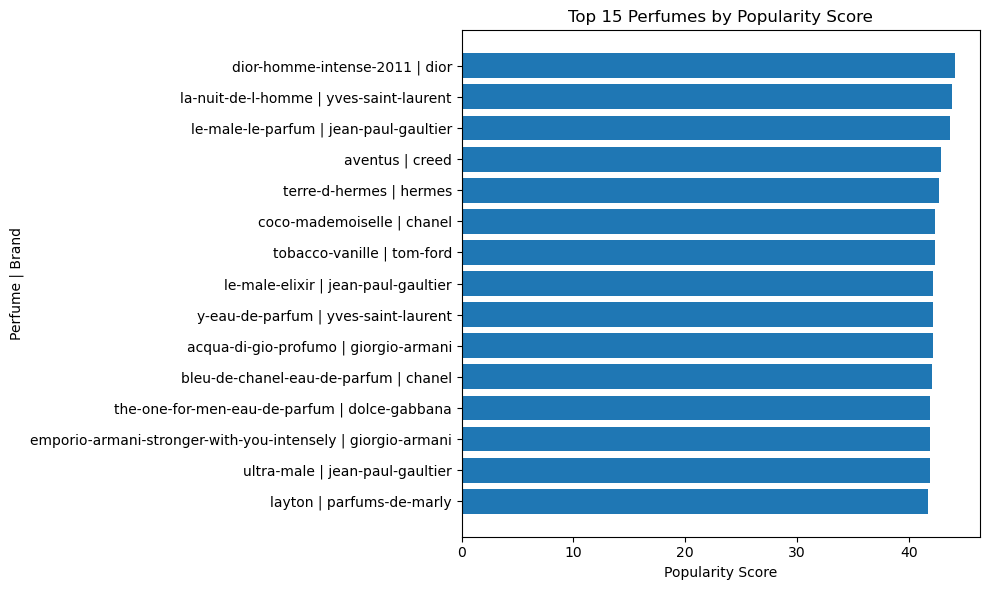

In [6]:
plt.figure(figsize=(10, 6))
plot = top_high_pop_perfumes.head(15).iloc[::-1]
plt.barh(plot["Perfume"] + " | " + plot["Brand"], plot["Popularity Score"])
plt.xlabel("Popularity Score")
plt.ylabel("Perfume | Brand")
plt.title("Top 15 Perfumes by Popularity Score")
plt.tight_layout()
plt.show()


## 2. 高热度香水中的 Gender 差异

比较整体数据和高热度组里 women、men、unisex 的占比差异。

In [7]:
high_pop_gender = high_pop["Gender"].value_counts(normalize=True).mul(100).round(2).reset_index()
high_pop_gender.columns = ["Gender", "Percentage in High Popularity Group"]

overall_gender = df["Gender"].value_counts(normalize=True).mul(100).round(2).reset_index()
overall_gender.columns = ["Gender", "Percentage Overall"]

gender_compare = pd.merge(overall_gender, high_pop_gender, on="Gender", how="outer").fillna(0)
gender_compare["Difference"] = (
    gender_compare["Percentage in High Popularity Group"] 
    - gender_compare["Percentage Overall"]
).round(2)

gender_compare


,Gender,Percentage Overall,Percentage in High Popularity Group,Difference
0,men,20.73,27.57,6.84
1,unisex,31.99,22.59,-9.40
2,women,47.28,49.83,2.55


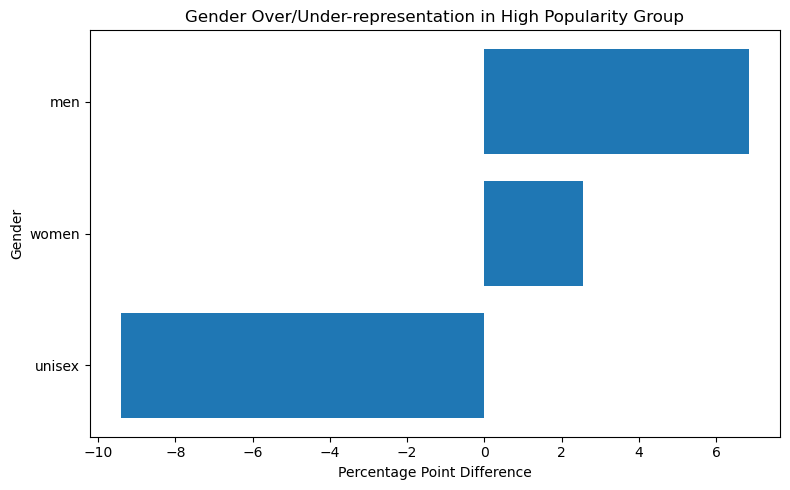

In [8]:
plt.figure(figsize=(8, 5))
gc = gender_compare.sort_values("Difference")
plt.barh(gc["Gender"], gc["Difference"])
plt.xlabel("Percentage Point Difference")
plt.ylabel("Gender")
plt.title("Gender Over/Under-representation in High Popularity Group")
plt.tight_layout()
plt.show()


## 3. 高热度香水中的香调 Lift

Lift 用来判断某个香调是否在高热度香水中过度出现。Lift > 1 说明它在热门香水中更常见。

In [9]:
accord_long = df[accord_cols].melt(value_name="accord").dropna()
all_accords = accord_long["accord"].unique()

rows = []
for accord in all_accords:
    overall_rate = df[accord_cols].eq(accord).any(axis=1).mean()
    high_rate = high_pop[accord_cols].eq(accord).any(axis=1).mean()
    total_count = df[accord_cols].eq(accord).any(axis=1).sum()
    high_count = high_pop[accord_cols].eq(accord).any(axis=1).sum()
    rows.append({
        "Accord": accord,
        "Overall Appearance Rate": overall_rate,
        "High Popularity Appearance Rate": high_rate,
        "Lift": high_rate / overall_rate if overall_rate > 0 else np.nan,
        "Total Count": total_count,
        "High Popularity Count": high_count
    })

accord_lift = pd.DataFrame(rows)
accord_lift = accord_lift.query(
    "`Total Count` >= 200 and `High Popularity Count` >= 30"
).sort_values("Lift", ascending=False)

accord_lift.head(25).round(3)


,Accord,Overall Appearance Rate,High Popularity Appearance Rate,Lift,Total Count,High Popularity Count
24,almond,0.018,0.035,1.944,437,85
35,coffee,0.009,0.017,1.897,216,41
54,nutty,0.011,0.018,1.574,273,43
50,tobacco,0.017,0.027,1.568,408,64
48,cacao,0.009,0.014,1.559,218,34
45,honey,0.015,0.024,1.556,366,57
21,vanilla,0.193,0.268,1.388,4644,645
34,lactonic,0.016,0.022,1.384,390,54
61,cinnamon,0.020,0.027,1.377,479,66
29,aldehydic,0.013,0.018,1.370,321,44


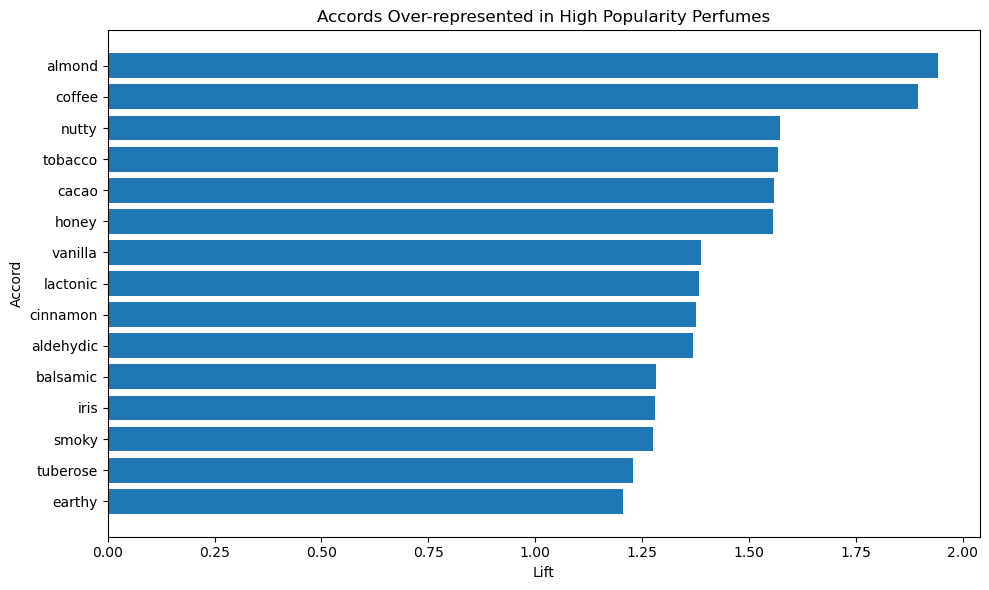

In [10]:
plt.figure(figsize=(10, 6))
plot = accord_lift.head(15).iloc[::-1]
plt.barh(plot["Accord"], plot["Lift"])
plt.xlabel("Lift")
plt.ylabel("Accord")
plt.title("Accords Over-represented in High Popularity Perfumes")
plt.tight_layout()
plt.show()


## 4. 不同 Gender 的香调差异

观察 women、men、unisex 三类香水的主流香调是否不同。

In [11]:
gender_accord_rows = []

for gender in df["Gender"].dropna().unique():
    subset = df[df["Gender"] == gender]
    for accord in all_accords:
        count = subset[accord_cols].eq(accord).any(axis=1).sum()
        rate = count / len(subset) if len(subset) else np.nan
        if count >= 50:
            gender_accord_rows.append({
                "Gender": gender,
                "Accord": accord,
                "Count": count,
                "Appearance Rate": rate
            })

gender_accord = pd.DataFrame(gender_accord_rows)

gender_top_accords = (
    gender_accord.sort_values(["Gender", "Appearance Rate"], ascending=[True, False])
    .groupby("Gender")
    .head(12)
    .round(3)
)

gender_top_accords


,Gender,Accord,Count,Appearance Rate
103,men,woody,3571,0.716
101,men,aromatic,3466,0.695
99,men,citrus,2613,0.524
112,men,fresh spicy,2574,0.516
111,men,warm spicy,2009,0.403
115,men,amber,1188,0.238
106,men,green,830,0.166
104,men,powdery,769,0.154
114,men,sweet,624,0.125
116,men,vanilla,617,0.124


## 5. 品牌数量和品牌热度是否相关

这一步用来验证：品牌香水数量多，是否代表这个品牌平均更受欢迎？

In [ ]:
brand_analysis = (
    df.groupby("Brand")
    .agg(
        perfume_count=("Perfume", "count"),
        avg_rating=("Rating Value", "mean"),
        median_rating_count=("Rating Count", "median"),
        avg_popularity_score=("Popularity Score", "mean"),
        total_rating_count=("Rating Count", "sum")
    )
    .dropna()
    .reset_index()
)

brand_analysis_filtered = brand_analysis.query("perfume_count >= 10").copy()

corr_count_pop = brand_analysis_filtered["perfume_count"].corr(
    brand_analysis_filtered["avg_popularity_score"]
)
corr_count_rating = brand_analysis_filtered["perfume_count"].corr(
    brand_analysis_filtered["avg_rating"]
)

print("Correlation: perfume_count vs avg_popularity_score =", round(corr_count_pop, 3))
print("Correlation: perfume_count vs avg_rating =", round(corr_count_rating, 3))

brand_analysis_filtered.sort_values("avg_popularity_score", ascending=False).head(25).round(3)


In [ ]:
plt.figure(figsize=(9, 6))
plt.scatter(
    np.log1p(brand_analysis_filtered["perfume_count"]), 
    brand_analysis_filtered["avg_popularity_score"],
    alpha=0.6
)
plt.xlabel("log(1 + Brand Perfume Count)")
plt.ylabel("Average Popularity Score")
plt.title("Brand Product Count vs Average Popularity Score")
plt.tight_layout()
plt.show()


## 6. 2000 年以来 Gender 趋势

观察不同 Gender 类别在每年新香水中的占比变化。

In [ ]:
year_gender = (
    df.dropna(subset=["Year", "Gender"])
    .assign(Year=lambda x: x["Year"].astype(int))
    .query("Year >= 2000 and Year <= 2024")
    .groupby(["Year", "Gender"])
    .size()
    .reset_index(name="count")
)

year_gender_total = year_gender.groupby("Year")["count"].transform("sum")
year_gender["percentage"] = year_gender["count"] / year_gender_total
year_gender_pivot = year_gender.pivot(index="Year", columns="Gender", values="percentage").fillna(0).reset_index()

plt.figure(figsize=(10, 6))
for gender in year_gender_pivot.columns:
    if gender != "Year":
        plt.plot(year_gender_pivot["Year"], year_gender_pivot[gender], label=gender)

plt.xlabel("Year")
plt.ylabel("Percentage")
plt.title("Gender Positioning Trend Since 2000")
plt.legend()
plt.tight_layout()
plt.show()


## 这一步怎么写进报告

高级分析部分可以围绕一句话展开：

本项目不是只做基础可视化，而是进一步构建综合热度指标，识别高热度香水画像，并从 Gender、香调和品牌三个角度分析哪些因素更可能与用户关注度相关。

这会比普通 EDA 更像一个完整的数据分析项目。